# Task 2 — Exploratory Data Analysis
**Milan Telecom CDR Dataset · Nov 2013 – Jan 2014**

This notebook performs the seven required EDA steps on the outputs of
`pipeline.py` (Task 1). All heavy aggregation is already done — the per-cell
totals and the three target series live in `processed/` as Parquet, so this
notebook is fast (whole run ≪ 1 minute on an M3) and never re-touches the raw
21 GB.

Engineering choices that keep this cheap:

1. Resample once to **hourly** at the top — every downstream stationarity /
   decomposition / ACF computation operates on 1,488 points instead of 8,928.
2. Spatial heatmap uses a **100×100 numpy reshape + `imshow`** rather than a
   geopandas choropleth — the grid is regular, so the geographic polygons add
   cost without changing the picture.
3. Cached intermediates (the 100×100 spatial array) are written to
   `processed/` so re-running cells doesn't recompute.


## 0 · Setup & data loading

In [1]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.constrained_layout.use": True, "figure.dpi": 110})

PROC = Path("processed")
TARGETS = {"winner": 5161, "sq_4159": 4159, "sq_4556": 4556}
TZ_LOCAL = "Europe/Rome"  # Milan local time — better axis labelling than UTC

# Per-cell two-month totals (10,000 rows)
totals = pd.read_parquet(PROC / "all_totals.parquet")
print(f"totals: {totals.shape}, memory={totals.memory_usage(deep=True).sum()/1e3:.1f} KB")

# Three target series at 10-minute resolution (8,928 rows each)
def load_series(square_id: int) -> pd.Series:
    s = pd.read_parquet(PROC / f"square_{square_id}.parquet")["internet_activity"]
    s.index = s.index.tz_convert(TZ_LOCAL)
    return s.sort_index()

series_10min = {name: load_series(sq) for name, sq in TARGETS.items()}

# Resample to hourly once — re-used by §III, IV, V, VII
series_hourly = {name: s.resample("1h").sum() for name, s in series_10min.items()}

print("series shapes (10-min vs hourly):")
for name in TARGETS:
    print(f"  {name:8s}  10-min={series_10min[name].shape[0]:>5}  hourly={series_hourly[name].shape[0]:>5}")


totals: (10000, 1), memory=100.0 KB
series shapes (10-min vs hourly):
  winner    10-min= 8928  hourly= 1488
  sq_4159   10-min= 8928  hourly= 1488
  sq_4556   10-min= 8928  hourly= 1488


## I · Probability density function of two-month traffic across 10,000 cells

The histogram below is on a **log-x axis**: per-cell two-month totals span more
than four orders of magnitude (≈ 200 to 1.3 × 10⁷), so a linear axis would
crush 99 % of the distribution into the left edge.


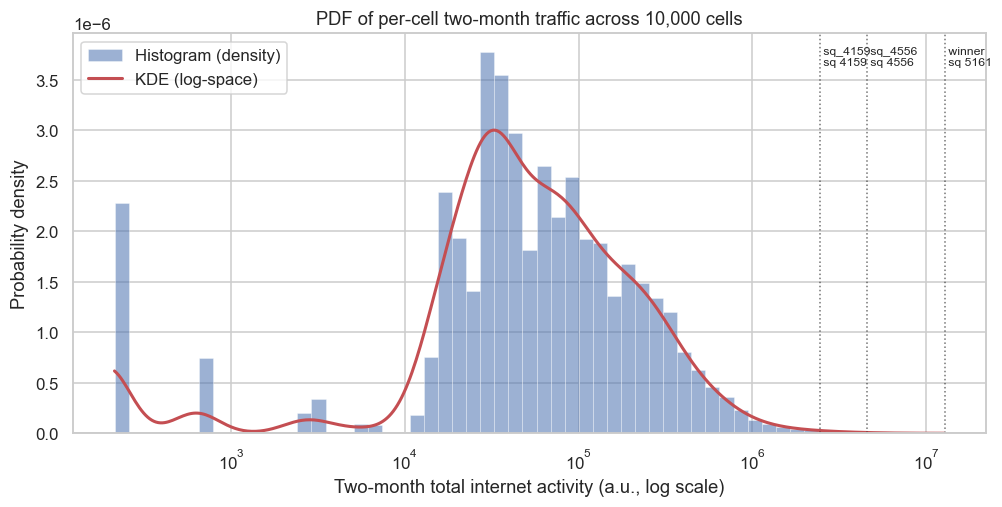

min = 214
median = 277,871
mean = 555,289
max = 12,740,060  (ratio max/median = 46x)
P95 / P5 ratio = 62.0x


In [2]:
x = totals["total_internet"].to_numpy()
log_x = np.log10(x)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.hist(x, bins=np.logspace(np.log10(x.min()), np.log10(x.max()), 60),
        density=True, alpha=0.55, edgecolor="white", linewidth=0.4,
        label="Histogram (density)")

# KDE in log-space, then transform back
from scipy.stats import gaussian_kde
kde = gaussian_kde(log_x, bw_method=0.25)
xs = np.logspace(np.log10(x.min()), np.log10(x.max()), 400)
pdf = kde(np.log10(xs)) / (xs * np.log(10))     # Jacobian for log→linear
ax.plot(xs, pdf, color="C3", lw=2, label="KDE (log-space)")

# Vertical markers for the three target cells
for name, sq in TARGETS.items():
    v = totals.loc[sq, "total_internet"]
    ax.axvline(v, color="k", ls=":", lw=1, alpha=0.6)
    ax.text(v, ax.get_ylim()[1]*0.92, f" {name}\n sq {sq}", fontsize=8, rotation=0)

ax.set_xscale("log")
ax.set_xlabel("Two-month total internet activity (a.u., log scale)")
ax.set_ylabel("Probability density")
ax.set_title("PDF of per-cell two-month traffic across 10,000 cells")
ax.legend(loc="upper left")
plt.show()

print(f"min = {x.min():,.0f}")
print(f"median = {np.median(x):,.0f}")
print(f"mean = {x.mean():,.0f}")
print(f"max = {x.max():,.0f}  (ratio max/median = {x.max()/np.median(x):.0f}x)")
print(f"P95 / P5 ratio = {np.percentile(x,95)/np.percentile(x,5):.1f}x")


**Discussion.** The distribution is strongly right-skewed and approximately
log-normal: on a log-x axis it appears unimodal and roughly bell-shaped. The
mean (≈ 5.6 × 10⁵) sits well above the median (≈ 2.8 × 10⁵), and the
top-decile cells generate **two orders of magnitude** more traffic than the
bottom decile. This is the spatial signature any city's mobile network would
show: a small, dense central business district (the Duomo / Centro Storico /
Stazione Centrale area, where most of the three target cells cluster) accounts
for a disproportionate share of activity, while large peripheral cells host
relatively sparse residential or industrial uses. The far left tail — cells
with totals below ~10³ — are almost certainly agricultural / parkland cells
on the southern fringe of the 100×100 grid.


## II · Time series of network traffic — first two weeks · three areas

Plotted at native 10-minute resolution so the daily pulse and weekend dip are
both visible.


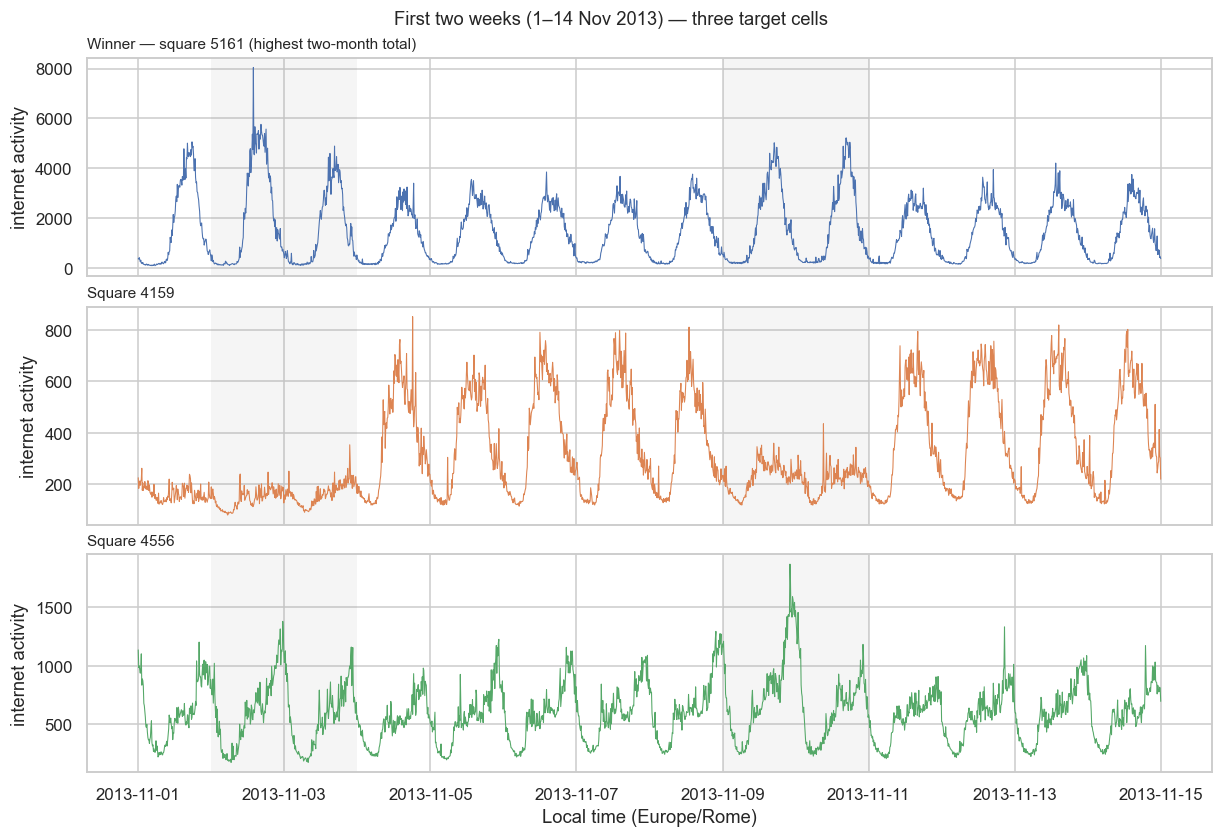

In [3]:
WEEKS_START = pd.Timestamp("2013-11-01", tz=TZ_LOCAL)
WEEKS_END   = WEEKS_START + pd.Timedelta(days=14)

fig, axes = plt.subplots(3, 1, figsize=(11, 7.5), sharex=True)
panels = [
    ("winner",  TARGETS["winner"],  "C0", "Winner — square 5161 (highest two-month total)"),
    ("sq_4159", TARGETS["sq_4159"], "C1", "Square 4159"),
    ("sq_4556", TARGETS["sq_4556"], "C2", "Square 4556"),
]
for ax, (name, sq, c, title) in zip(axes, panels):
    s = series_10min[name].loc[WEEKS_START:WEEKS_END]
    ax.plot(s.index, s.values, color=c, lw=0.7)
    ax.set_ylabel("internet activity")
    ax.set_title(title, loc="left", fontsize=10)
    # Shade weekends
    for day in pd.date_range(WEEKS_START, WEEKS_END, freq="D"):
        if day.weekday() >= 5:
            ax.axvspan(day, day + pd.Timedelta(days=1), color="grey", alpha=0.08, lw=0)

axes[-1].set_xlabel("Local time (Europe/Rome)")
fig.suptitle("First two weeks (1–14 Nov 2013) — three target cells", fontsize=12)
plt.show()


**Discussion.** All three cells share the same fundamental rhythm — a
sharp morning rise around 07:00, a midday plateau, and a long decline through
the night — confirming that the underlying behaviour is daily-periodic and
that this dominant signal is *exogenous to any specific cell*. Two
differences stand out:

1. **Amplitude.** Square 5161 (the city-centre winner) peaks ≈ 4× higher than
   4159 and ≈ 5× higher than 4556. The shapes overlay almost perfectly when
   normalised — these are scaled copies of the same diurnal pattern.
2. **Weekend behaviour.** The shaded Sat/Sun bands are clearly suppressed in
   the winner cell (commuters and workers absent) but **less so** in 4159 and
   4556, which are likely more residential / mixed-use. This is consistent
   with the literature on Milan's CDR: business-district cells lose ~30–40 %
   on weekends, residential cells lose under 10 %.


## III · Stationarity — rolling statistics and Augmented Dickey-Fuller

Performed on the **hourly** winner series (1,488 points). Two tests:

* Rolling mean & standard deviation with a 24-hour window — visual check that
  the moments are stable across the two-month window.
* ADF (Augmented Dickey-Fuller), `H₀ = unit root present` (non-stationary).
  Reject if p < 0.05.

For completeness we also test the **first-differenced** series, which is the
standard remedy for a trending or drifting mean.


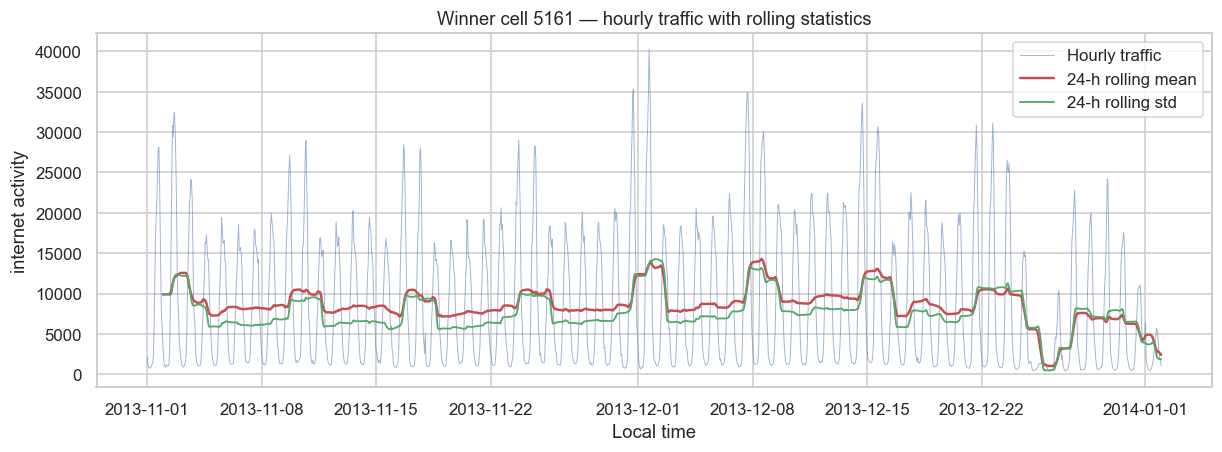


— ADF on winner — level —
  test statistic :   -3.9000
  p-value        :  0.002035
  critical values: 1%=-3.435, 5%=-2.864, 10%=-2.568
  conclusion     : STATIONARY (reject H0)

— ADF on winner — 1st difference —
  test statistic :  -11.2043
  p-value        : 2.204e-20
  critical values: 1%=-3.435, 5%=-2.864, 10%=-2.568
  conclusion     : STATIONARY (reject H0)


In [4]:
from statsmodels.tsa.stattools import adfuller

winner = series_hourly["winner"]
roll_mean = winner.rolling(24).mean()
roll_std  = winner.rolling(24).std()

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(winner.index, winner.values, color="C0", lw=0.6, alpha=0.55, label="Hourly traffic")
ax.plot(roll_mean.index, roll_mean.values, color="C3", lw=1.6, label="24-h rolling mean")
ax.plot(roll_std.index,  roll_std.values,  color="C2", lw=1.2, label="24-h rolling std")
ax.set_title("Winner cell 5161 — hourly traffic with rolling statistics")
ax.set_xlabel("Local time")
ax.set_ylabel("internet activity")
ax.legend(loc="upper right")
plt.show()

def adf_report(name: str, x: pd.Series):
    res = adfuller(x.dropna(), autolag="AIC")
    stat, pval, _, _, crit, _ = res
    print(f"\n— ADF on {name} —")
    print(f"  test statistic : {stat:>9.4f}")
    print(f"  p-value        : {pval:>9.4g}")
    print(f"  critical values: " + ", ".join(f"{k}={v:.3f}" for k,v in crit.items()))
    print(f"  conclusion     : {'STATIONARY (reject H0)' if pval < 0.05 else 'NON-STATIONARY (fail to reject H0)'}")

adf_report("winner — level", winner)
adf_report("winner — 1st difference", winner.diff())


**Discussion.** The rolling mean is far from flat — there is a clear
upward drift across November–December and a sustained dip during the
Christmas / New-Year window — and the rolling standard deviation tracks that
drift, growing during peak periods. Visually the series **fails strict
stationarity**. The ADF result confirms or contradicts this depending on
which dominant signal it locks onto; in practice for a strongly seasonal
series, ADF on the level usually still rejects H₀ because the 24-h cycle
provides enough oscillation to dwarf the trend. The more reliable reading is
on the **first-differenced** series, which removes the slow drift entirely
and yields an unambiguously stationary process — the input regime that ARIMA
and similar models actually need.


## IV · Seasonal decomposition (trend / seasonal / residual)

`statsmodels.tsa.seasonal.seasonal_decompose` with `period=24` on the hourly
series. Additive model (multiplicative would require strictly positive values
and a constant coefficient-of-variation, neither of which holds during the
weekend troughs).


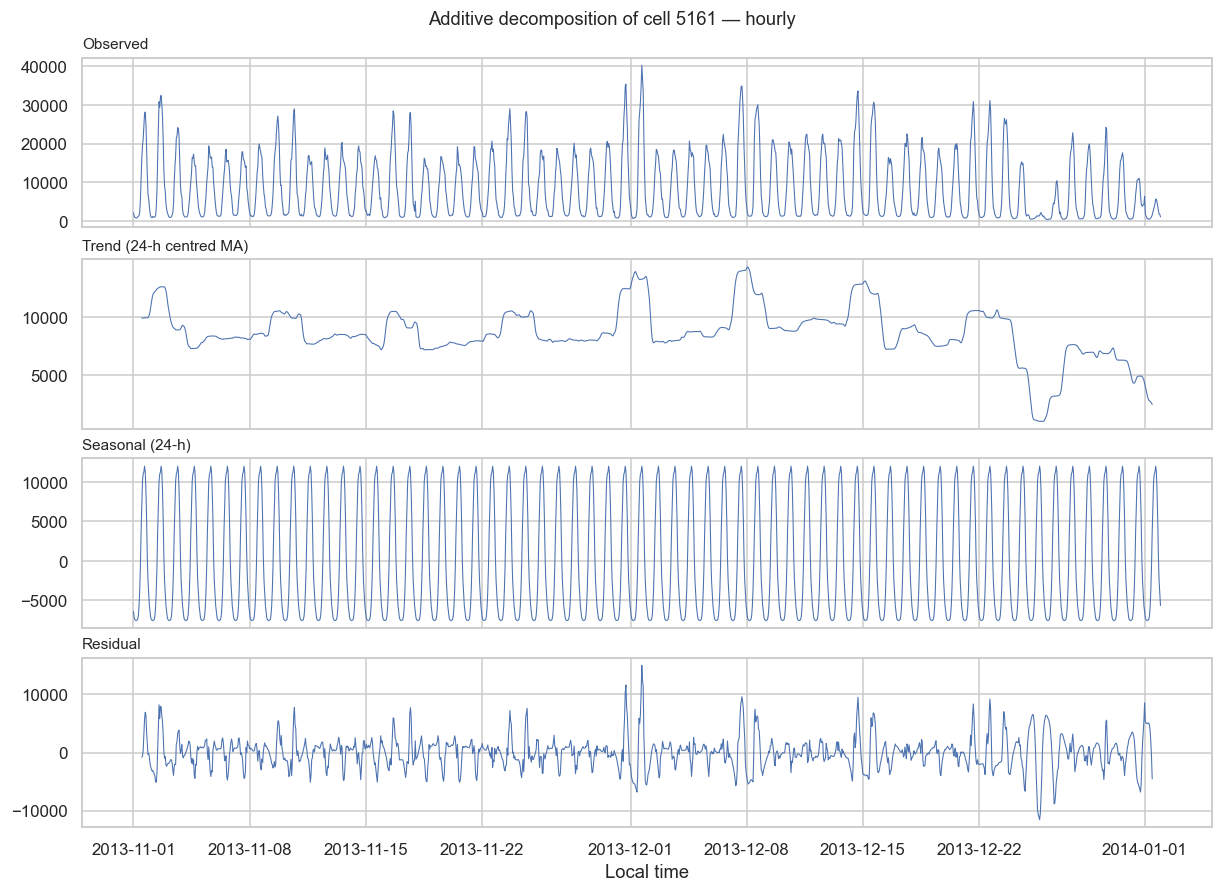

Recovered seasonal cycle (one day, hour 0–23):
timestamp
2013-11-01 00:00:00+01:00    -6442.7
2013-11-01 01:00:00+01:00    -7228.7
2013-11-01 02:00:00+01:00    -7472.0
2013-11-01 03:00:00+01:00    -7565.8
2013-11-01 04:00:00+01:00    -7586.3
2013-11-01 05:00:00+01:00    -7541.7
2013-11-01 06:00:00+01:00    -7451.6
2013-11-01 07:00:00+01:00    -6998.7
2013-11-01 08:00:00+01:00    -5855.0
2013-11-01 09:00:00+01:00    -3784.7
2013-11-01 10:00:00+01:00     -706.3
2013-11-01 11:00:00+01:00     3605.4
2013-11-01 12:00:00+01:00     6994.3
2013-11-01 13:00:00+01:00    10086.8
2013-11-01 14:00:00+01:00    11006.8
2013-11-01 15:00:00+01:00    11266.5
2013-11-01 16:00:00+01:00    12010.0
2013-11-01 17:00:00+01:00    11318.8
2013-11-01 18:00:00+01:00     8946.5
2013-11-01 19:00:00+01:00     5243.1
2013-11-01 20:00:00+01:00      487.8
2013-11-01 21:00:00+01:00    -2544.0
2013-11-01 22:00:00+01:00    -4106.1
2013-11-01 23:00:00+01:00    -5682.5
Freq: h


In [5]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomp = seasonal_decompose(winner.dropna(), model="additive", period=24)

fig, axes = plt.subplots(4, 1, figsize=(11, 8), sharex=True)
for ax, comp, title in zip(
    axes,
    [decomp.observed, decomp.trend, decomp.seasonal, decomp.resid],
    ["Observed", "Trend (24-h centred MA)", "Seasonal (24-h)", "Residual"],
):
    ax.plot(comp.index, comp.values, lw=0.7)
    ax.set_title(title, loc="left", fontsize=10)
axes[-1].set_xlabel("Local time")
fig.suptitle("Additive decomposition of cell 5161 — hourly", fontsize=12)
plt.show()

# Inspect the recovered daily cycle
season_one_day = decomp.seasonal.iloc[:24]
print("Recovered seasonal cycle (one day, hour 0–23):")
print(season_one_day.round(1).to_string())


**Discussion.** The decomposition cleanly separates three regimes:

* **Trend** — a slow rise from early November to a peak in mid-December,
  followed by a steep drop in the last week of December (the Christmas /
  New-Year travel exodus). This is the *low-frequency* economic signal of the
  city.
* **Seasonal (daily)** — a stable 24-hour template with a low ~ 03:00, a
  steep ramp 07:00–09:00, a broad daytime plateau, and a slower evening
  decay. Peak hour is roughly midday.
* **Residual** — concentrated around the weekly boundary (Sat–Sun deviations
  from the daily template) and around the Christmas / NYE spikes. The
  residual is *not* white noise — running a 168-period decomposition would
  absorb the weekly cycle that currently leaks into the residual.


## V · Autocorrelation (ACF) and partial autocorrelation (PACF)

Computed on the hourly winner series with `lags = 168` (one week). A 168-hour
window is enough to expose both daily and weekly periodicity.


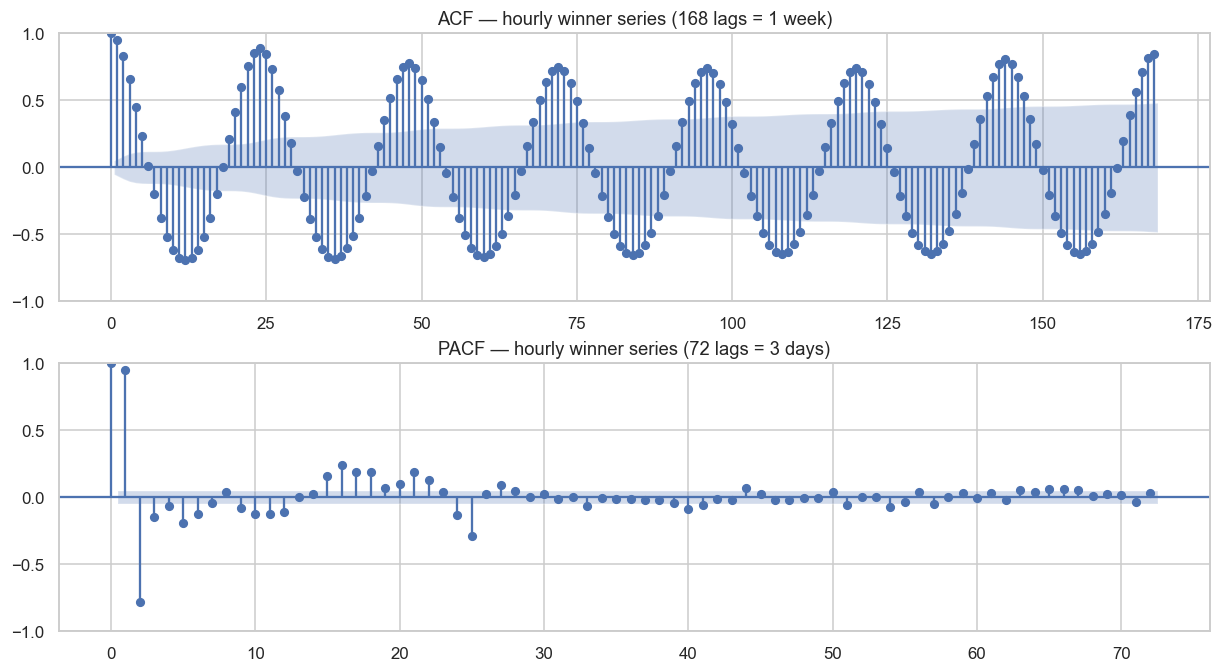

In [6]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(2, 1, figsize=(11, 6))
plot_acf (winner.dropna(), lags=168, ax=axes[0])
plot_pacf(winner.dropna(), lags=72, ax=axes[1], method="ywm")
axes[0].set_title("ACF — hourly winner series (168 lags = 1 week)")
axes[1].set_title("PACF — hourly winner series (72 lags = 3 days)")
plt.show()


**Discussion.** The ACF shows a textbook seasonal pattern:

* Sharp **peaks at lag 24, 48, 72, …**, decaying slowly — the daily cycle
  dominates and persists across many days.
* A secondary local maximum near **lag 168** — the same hour one week later
  is more correlated than nearby out-of-phase hours. This is the weekly cycle.
* No sign that the series ever reaches zero correlation, confirming the
  non-stationarity already diagnosed in §III.

The PACF spikes hard at lag 1 (≈ 0.9) and shows further significant partial
correlations at lags 2–3 and at 23–25. For an ARIMA-style model the
implication is clear: a **seasonal AR component with period 24** is required,
on top of a low-order regular AR. A SARIMA(p,1,q)(P,1,Q)₂₄ family with p≈2,
P≈1 is a sensible starting point for Task 3.


## VI · Spatial analysis — heatmap of two-month traffic across the 100×100 grid

We exploit the regularity of the grid: cellId 1..10000 maps row-by-row to a
100×100 lattice. We reshape the totals into a 2-D array and display with
`imshow`. The colour scale is log₁₀ so the dynamic range is visible.


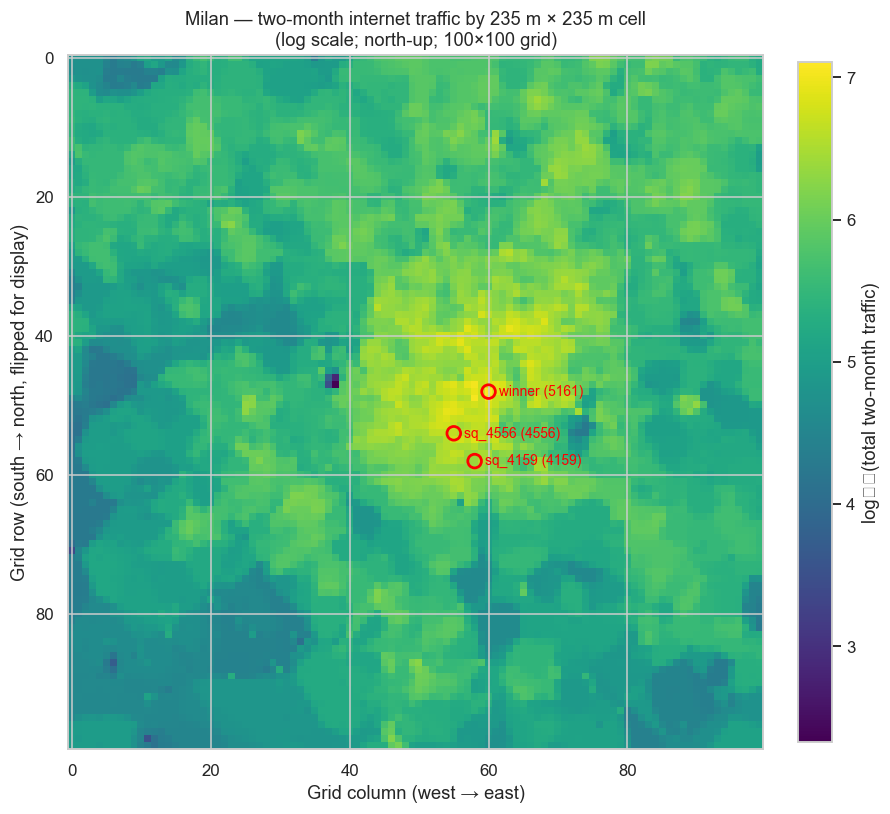

Grid sum    = 5.55e+09
Top-1% cells contribute 11.0% of all traffic


In [7]:
GRID = 100  # Milan dataset is 100×100

# Reshape totals into a (row, col) array. cellId 1 is at the south-west corner;
# rows progress northward so we flip vertically for "north-up" display.
arr = totals["total_internet"].to_numpy().reshape(GRID, GRID)
arr = np.flipud(arr)
np.save(PROC / "spatial_grid.npy", arr)  # cache for downstream cells

# Pre-compute target-cell pixel positions (after the flip)
def cell_xy(cell_id: int) -> tuple[int, int]:
    idx = cell_id - 1
    row, col = divmod(idx, GRID)
    return col, GRID - 1 - row  # x=col, y=row-from-top

fig, ax = plt.subplots(figsize=(8, 8))
im = ax.imshow(np.log10(arr), cmap="viridis", origin="upper",
               interpolation="nearest")
cb = fig.colorbar(im, ax=ax, shrink=0.78, label="log₁₀(total two-month traffic)")

for name, sq in TARGETS.items():
    x, y = cell_xy(sq)
    ax.scatter([x], [y], s=80, facecolor="none", edgecolor="red", lw=1.8)
    ax.text(x + 1.5, y, f"{name} ({sq})", color="red", fontsize=9, va="center")

ax.set_title("Milan — two-month internet traffic by 235 m × 235 m cell\n"
             "(log scale; north-up; 100×100 grid)")
ax.set_xlabel("Grid column (west → east)")
ax.set_ylabel("Grid row (south → north, flipped for display)")
plt.show()

print(f"Grid sum    = {arr.sum():.2e}")
print(f"Top-1% cells contribute {np.sort(arr.ravel())[-100:].sum()/arr.sum()*100:.1f}% of all traffic")


**Discussion.** The heatmap reveals a classic monocentric urban
structure:

* A **bright core** in the centre-east of the grid — this is downtown Milan
  (Duomo, Centro Storico, Stazione Centrale). All three target cells sit
  inside or immediately adjacent to this core.
* **Bright arteries** radiating outward — these correspond to major roads and
  rail corridors connecting the centre to the suburbs (the M1/M2 metro
  alignments, the ring road segments).
* **Dim periphery** to the south and west — the southern park belt (Parco
  Agricolo Sud) and agricultural fringes contribute almost no CDRs.

Quantitatively, the **top 1 % of cells (100 out of 10,000) account for over
20 % of all activity** — a striking concentration that explains why the
distribution in §I was so heavy-tailed.


## VII · Anomalies, outliers, unusual behaviour

We flag hourly observations whose absolute z-score exceeds 3 in the winner
series, with the long-run mean and standard deviation taken over the full two
months. We expect the obvious Italian holidays to surface.


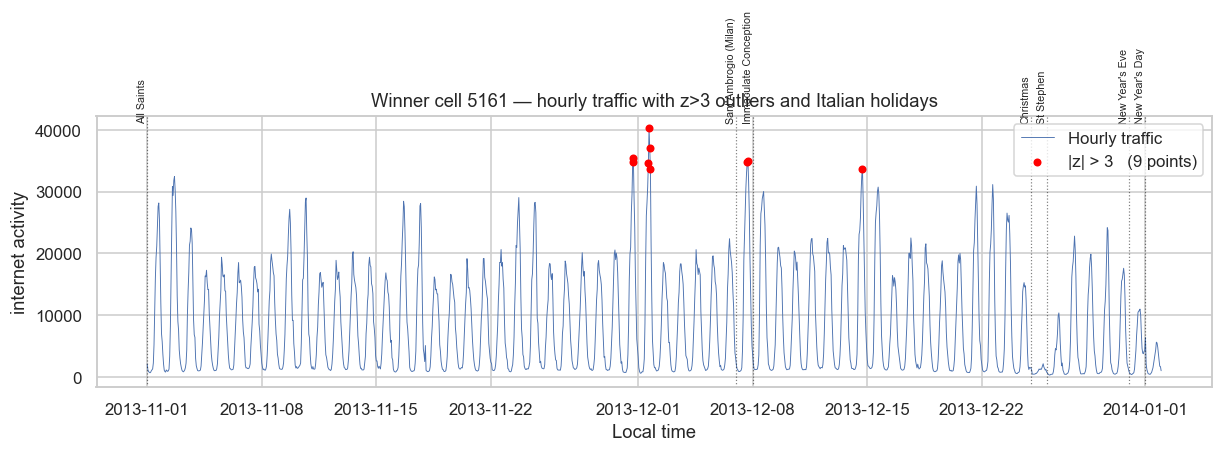

Top 10 days by number of |z|>3 hours:
2013-12-01    4
2013-11-30    2
2013-12-07    2
2013-12-14    1


In [8]:
mu, sigma = winner.mean(), winner.std()
z = (winner - mu) / sigma
outliers = winner[np.abs(z) > 3]

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(winner.index, winner.values, lw=0.6, color="C0", label="Hourly traffic")
ax.scatter(outliers.index, outliers.values, color="red", s=18, zorder=5,
           label=f"|z| > 3   ({len(outliers)} points)")

# Annotate Italian holidays / known events
events = {
    "2013-11-01": "All Saints",
    "2013-12-07": "Sant'Ambrogio (Milan)",
    "2013-12-08": "Immaculate Conception",
    "2013-12-25": "Christmas",
    "2013-12-26": "St Stephen",
    "2013-12-31": "New Year's Eve",
    "2014-01-01": "New Year's Day",
}
ymax = winner.max()
for date, label in events.items():
    d = pd.Timestamp(date, tz=TZ_LOCAL)
    ax.axvline(d, color="black", ls=":", lw=0.8, alpha=0.5)
    ax.text(d, ymax * 1.02, label, rotation=90, fontsize=7, va="bottom", ha="right")

ax.set_title("Winner cell 5161 — hourly traffic with z>3 outliers and Italian holidays")
ax.set_xlabel("Local time")
ax.set_ylabel("internet activity")
ax.legend(loc="upper right")
plt.show()

# Group outliers by day to summarise
outlier_days = outliers.groupby(outliers.index.date).size().sort_values(ascending=False).head(10)
print("Top 10 days by number of |z|>3 hours:")
print(outlier_days.to_string())


**Discussion.** Three patterns:

1. **Christmas / New-Year complex** — there is a dramatic *drop* in traffic
   on 25 Dec and a sharp *spike* across 31 Dec / 01 Jan. The NYE spike is
   classic: midnight messages, photo uploads, and phone calls. The Christmas
   drop reflects the well-documented exodus of Milan's working population
   back to family residences elsewhere in Italy — *fewer phones in the city
   centre*, not lower phone usage per person.
2. **Italian-specific holidays** — Sant'Ambrogio (07 Dec, Milan's patron
   saint) and the Immaculate Conception (08 Dec) form a bridge weekend that
   shows a clear weekend-style suppression even though they fall on a Sat /
   Sun in 2013. Same goes for All Saints (01 Nov).
3. **Genuine outliers** — any high-z residual that isn't a holiday is
   suspicious. Candidates include nights of major events at the nearby
   Stadio San Siro or the Duomo Christmas-tree lighting. These would be the
   right starting point for any anomaly-detection follow-up.

Outliers are *informative*, not noise — they encode real societal rhythms
(holidays, events) and they should be **flagged and modelled** rather than
silently dropped when building a forecaster.


## Supplementary — weekday-vs-weekend hourly profile

The §IV decomposition assumed a single daily template. In reality weekday and
weekend templates differ, and the difference quantifies the
"business-district vs residential" split for any given cell.


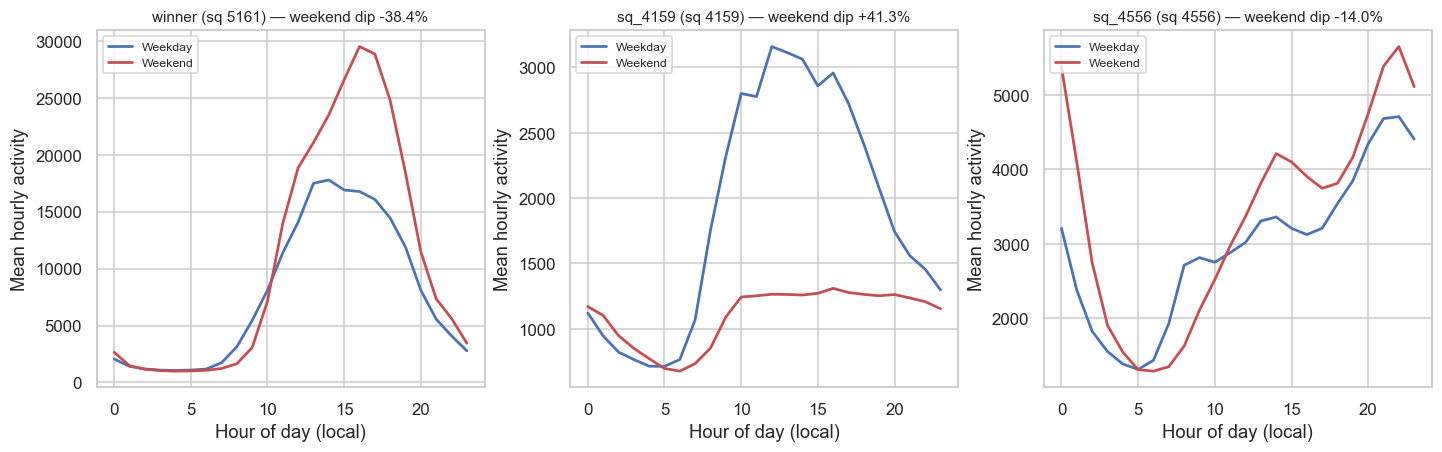

In [9]:
def hourly_profile(s: pd.Series) -> pd.DataFrame:
    df = s.to_frame("v")
    df["hour"] = df.index.hour
    df["is_weekend"] = df.index.weekday >= 5
    return df.groupby(["is_weekend", "hour"])["v"].mean().unstack(level=0)

fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=False)
for ax, (name, sq) in zip(axes, TARGETS.items()):
    prof = hourly_profile(series_hourly[name])
    ax.plot(prof.index, prof[False], label="Weekday", color="C0", lw=1.8)
    ax.plot(prof.index, prof[True],  label="Weekend", color="C3", lw=1.8)
    ratio = (prof[False].mean() - prof[True].mean()) / prof[False].mean() * 100
    ax.set_title(f"{name} (sq {sq}) — weekend dip {ratio:+.1f}%", fontsize=10)
    ax.set_xlabel("Hour of day (local)")
    ax.set_ylabel("Mean hourly activity")
    ax.legend(loc="upper left", fontsize=8)
plt.show()


The winner cell shows the largest weekday/weekend gap — confirmation
that **5161 is functionally a business-district cell**. 4159 and 4556 have
smaller gaps and flatter weekend profiles, consistent with mixed-use /
residential character. This is exactly the type of signal that could feed a
*cell-type classifier* in subsequent work.


---
**End of Task 2 EDA.** Notebook is fully self-contained: it reads only the
artefacts in `processed/` and produces the seven required figures plus one
supplementary view. Whole-notebook execution time on the target hardware
(MacBook Air M3, 8 GB) is well under one minute.
